# Predictive Maintenance with NASA C-MAPSS
## Overview

Remaining Useful Life (RUL), Failure Risk, Explainability, and Maintenance Decisions

**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Simulation - **FD001**  
**Project type:** Predictive maintenance / multivariate time series / regression + classification  
**Primary goal:** Predict how many operating cycles an engine has left before failure.

This notebook is designed as a **learning project and portfolio project**. It deliberately starts with familiar tabular machine-learning methods and then layers in the time-dependent ideas that make predictive maintenance different.


## Project roadmap

1. Frame the predictive-maintenance business problem
2. Download and load NASA C-MAPSS FD001
3. Audit data quality and explore degradation behavior
4. Create the Remaining Useful Life (RUL) target
5. Split data **by engine** to prevent leakage
6. Build a naive baseline
7. Compare Linear Regression, Decision Tree, Random Forest, and XGBoost
8. Engineer historical features: lags, rolling statistics, changes, and slopes
9. Test whether sensor history improves RUL prediction
10. Tune XGBoost using grouped cross-validation
11. Explain the final regression model with SHAP
12. Evaluate on NASA's official FD001 test trajectories
13. Reframe the problem as **failure within 30 cycles** classification
14. Compare Logistic Regression, Random Forest, and XGBoost classifiers
15. Optimize the classification threshold using hypothetical maintenance costs
16. Explore a PCA-based machine health index and anomaly detection
17. Summarize findings, business recommendations, limitations, and next steps

## Business understanding

Unexpected equipment failures can cause downtime, missed production, emergency labor, secondary damage, and lost revenue. Preventive maintenance reduces failure risk, but maintaining equipment too early also wastes useful component life and labor.

This project therefore asks two related questions:


> How many operational cycles remain before an engine fails?

The target variable, Remaining Useful Life (RUL), measured in cycles will be answered through regression.


> **Is an engine likely to fail within the next 30 cycles?**

This creates an focused/actionable maintenance alert rather than only a numerical life estimate and will be answered through classification.

### Purpose

- A regression model supports planning and prioritization.
- A classification model is easier to connect to an operational rule such as "inspect this engine".
- The final threshold should reflect the relative business cost of an unnecessary inspection versus a missed imminent failure.



## About the NASA C-MAPSS dataset

NASA describes C-MAPSS as a collection of **multivariate engine run-to-failure time series**. Each row is one engine at one operating cycle. The files contain:

- engine / unit identifier
- cycle number
- 3 operational settings
- 21 sensor measurements

Each engine begins in normal operation and eventually develops a fault. In the **training set**, the trajectory continues until failure. In the **test set**, each engine trajectory stops before failure, and NASA supplies the true number of remaining cycles after that stopping point.

**FD001** contains:

- 100 training engine trajectories
- 100 test engine trajectories
- 1 operating condition
- 1 fault mode (high-pressure compressor degradation)

**NASA sources**

- Dataset page: https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data
- NASA Prognostics Center of Excellence repository: https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/
- Dataset citation: A. Saxena and K. Goebel (2008), *Turbofan Engine Degradation Simulation Data Set*, NASA Prognostics Data Repository.


## Reference

NASA Prognostics Center of Excellence (PCoE): A. Saxena and K. Goebel (2008), *Turbofan Engine Degradation Simulation Data Set*, NASA Ames Research Center, Moffett Field, CA.

Dataset information and current download are available from NASA's PCoE repository:
https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/

## Imports

In [1]:
from pathlib import Path
import time
import warnings
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    IsolationForest,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBClassifier, XGBRegressor
import shap

warnings.filterwarnings("ignore")

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Load the datasets

NASA's text files do not include column headers, so we assign descriptive names. Per documentation:
- There are 26 columns total: 2 identifiers, 3 operating settings, and 21 sensor measurements.
    - Column 1: Engine unit number (unique identifier)
    - Column 2: Time cycle (operational cycle number)
    - Columns 3-5: 3 Operational settings (flight altitude, throttle resolver angle, etc.)
    - Columns 6-26: 21 Sensor measurements (temperatures, pressures, speeds, ratios)

In [2]:
setting_cols = [f"setting_{i}" for i in range(1, 4)]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
column_names = ["engine_id", "cycle"] + setting_cols + sensor_cols

train = pd.read_csv("data/train_FD001.txt",
                    sep = r'\s+',
                    header = None,
                    names = column_names,
                    index_col = False
                   )

test = pd.read_csv("data/test_FD001.txt",
                   sep = r"\s+",
                   header = None,
                   names = column_names,
                   index_col = False
                  )

test_rul = pd.read_csv("data/RUL_FD001.txt",
                   sep = r"\s+",
                   header = None,
                   names = ["rul"]
                  ).assign(engine_id = lambda df: range(1, len(df) + 1))

print("Training: ", train.shape)
print("Test: ", test.shape)
print("Test RUL: ", test_rul.shape)

test.sample(3, random_state = RANDOM_STATE)

Training:  (20631, 26)
Test:  (13096, 26)
Test RUL:  (100, 2)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
7306,57,101,-0.001,-0.000,100.000,518.670,642.630,"1,584.560","1,406.830",14.620,21.610,553.330,"2,388.140","9,050.400",1.300,47.510,522.330,"2,388.120","8,128.100",8.488,0.030,395,2388,100.000,38.770,23.333
3126,27,65,0.001,-0.000,100.000,518.670,642.140,"1,582.960","1,397.470",14.620,21.610,554.630,"2,388.050","9,057.130",1.300,47.210,522.210,"2,388.090","8,132.580",8.418,0.030,391,2388,100.000,38.920,23.513
749,8,75,-0.004,-0.000,100.000,518.670,642.100,"1,589.340","1,411.940",14.620,21.610,553.530,"2,388.140","9,048.600",1.300,47.390,521.320,"2,388.100","8,131.720",8.407,0.030,393,2388,100.000,38.900,23.320


## EDA
Check basic data quality:

- expected number of engines
- missing values
- duplicate `(engine_id, cycle)` records
- engine lifetime distribution
- constant or near-constant sensors

### Create RUL variable
For the training set, we know the cycle on which each engine fails (the max cycle given). Therefore:

> Remaining Useful Life (RUL) = failure cycle - cycle

In [3]:
train.query("engine_id == 1").tail(3)
# engine_id 1 fails at cycle 192

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
189,1,190,-0.003,0.000,100.000,518.670,643.640,"1,599.220","1,425.950",14.620,21.610,551.290,"2,388.290","9,040.580",1.300,48.330,520.040,"2,388.350","8,112.580",8.522,0.030,398,2388,100.000,38.490,23.067
190,1,191,-0.000,-0.000,100.000,518.670,643.340,"1,602.360","1,425.770",14.620,21.610,550.920,"2,388.280","9,042.760",1.300,48.150,519.570,"2,388.300","8,114.610",8.517,0.030,394,2388,100.000,38.450,23.130
191,1,192,0.001,-0.000,100.000,518.670,643.540,"1,601.410","1,427.200",14.620,21.610,551.250,"2,388.320","9,033.220",1.300,48.250,520.080,"2,388.320","8,110.930",8.511,0.030,396,2388,100.000,38.480,22.965


In [4]:
# Create failure_cycle variable
train = (train
    .assign(failure_cycle = lambda df: df.groupby("engine_id")["cycle"].transform("max"))
    .assign(rul = lambda df: df["failure_cycle"] - df["cycle"])
)

train.query("engine_id == 1").sample(3)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,failure_cycle,rul
172,1,173,-0.003,0.000,100.000,518.670,642.970,"1,590.690","1,425.270",14.620,21.610,552.130,"2,388.220","9,048.820",1.300,47.900,520.110,"2,388.230","8,121.640",8.509,0.030,395,2388,100.000,38.590,23.179,192,19
26,1,27,-0.001,-0.000,100.000,518.670,642.440,"1,590.470","1,401.840",14.620,21.610,554.070,"2,388.020","9,047.960",1.300,47.370,522.000,"2,388.130","8,134.600",8.405,0.030,393,2388,100.000,38.990,23.447,192,165
41,1,42,0.001,-0.000,100.000,518.670,642.120,"1,584.660","1,401.380",14.620,21.610,553.940,"2,388.080","9,057.060",1.300,47.490,522.230,"2,388.050","8,130.880",8.414,0.030,392,2388,100.000,39.000,23.375,192,150


### Basic info

In [5]:
pd.Series({
    "training_rows": len(train),
    "training_engines": train["engine_id"].nunique(),
    "test_rows": len(test),
    "test_engines": test["engine_id"].nunique(),
    "missing_training_values": int(train.isna().sum().sum()),
    "duplicate_engine_cycles": int(train.duplicated(["engine_id", "cycle"]).sum()),
}).to_frame("value")

,value
training_rows,20631
training_engines,100
test_rows,13096
test_engines,100
missing_training_values,0
duplicate_engine_cycles,0


In [6]:
pd.DataFrame({
    "nunique": train[column_names].nunique(),
    "std": train[column_names].std(),
    "min": train[column_names].min(),
    "max": train[column_names].max(),
}).sort_values("std")

,nunique,std,min,max
sensor_1,1,0.000,518.670,518.670
setting_3,1,0.000,100.000,100.000
sensor_10,1,0.000,1.300,1.300
sensor_18,1,0.000,"2,388.000","2,388.000"
sensor_19,1,0.000,100.000,100.000
sensor_16,1,0.000,0.030,0.030
sensor_5,1,0.000,14.620,14.620
setting_2,13,0.000,-0.001,0.001
sensor_6,2,0.001,21.600,21.610
setting_1,158,0.002,-0.009,0.009


*Many sensors/settings have a single unique value*

### Engine lifetime distribution

Different engines fail after different numbers of cycles. That variation is useful: the model must learn degradation patterns rather than simply memorize one fixed lifespan.

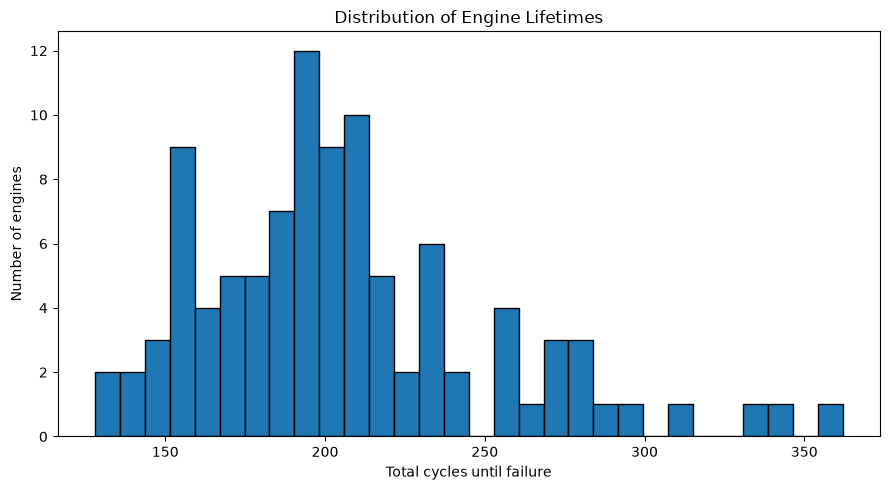

In [7]:
plt.figure(figsize = (9, 5))
plt.hist(
    train.groupby(["engine_id"])["failure_cycle"].max(), 
    bins = 30, 
    edgecolor = "black"
)
plt.title("Distribution of Engine Lifetimes")
plt.xlabel("Total cycles until failure")
plt.ylabel("Number of engines")
plt.tight_layout()
plt.show()

### Correlation of the sensors

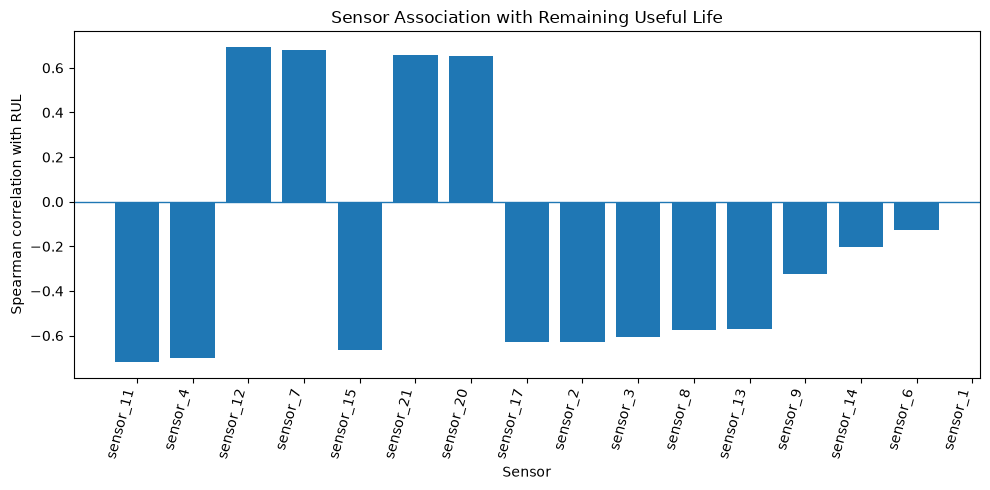

In [8]:
# Rank sensors by absolute Spearman correlation with RUL for EDA only.
sensor_rul_corr = (
    train[sensor_cols + ["rul"]]
        .corr(method = "spearman")["rul"]
        .drop("rul")
        .sort_values(key = np.abs, ascending = False)
        .rename("spearman_corr_with_rul").to_frame()
)

plt.figure(figsize = (10, 5))
plt.bar(sensor_rul_corr.index, sensor_rul_corr["spearman_corr_with_rul"])

plt.axhline(0, linewidth = 1)
plt.title("Sensor Association with Remaining Useful Life")

plt.xlabel("Sensor")
plt.ylabel("Spearman correlation with RUL")
plt.xticks(rotation = 75, ha = "right")

plt.tight_layout()
plt.show()

### Correlated Sensors over Cycle/Time 

In [9]:
example_sensors = sensor_rul_corr.abs().head(4).index.tolist()
example_sensors

['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']

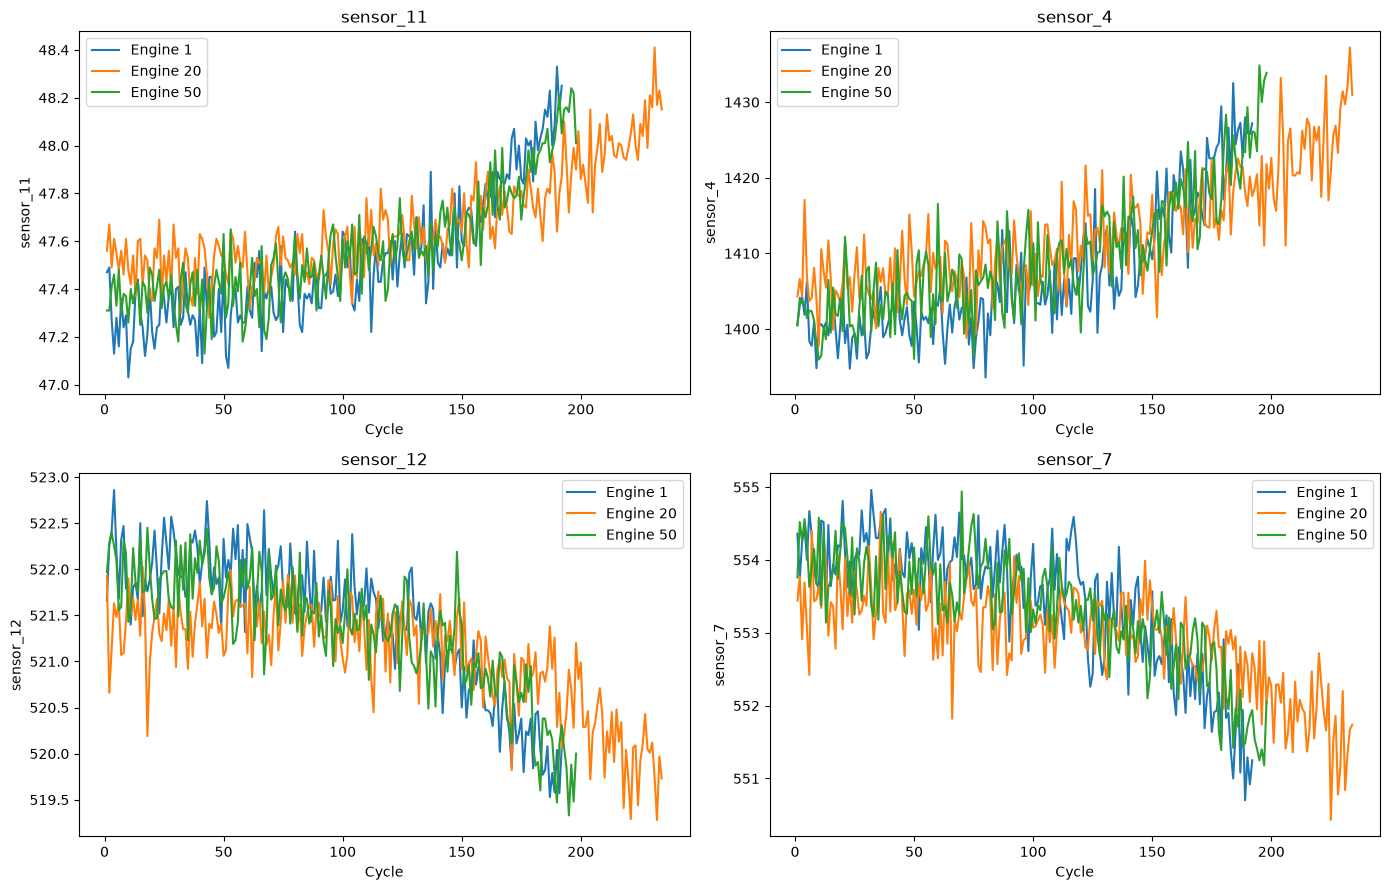

In [10]:
# Plot a few highly associated sensors for a few example engines.

example_engines = [1, 20, 50]

fig, axes = plt.subplots(2, 2, figsize = (14, 9))
axes = axes.flatten()

for ax, sensor in zip(axes, example_sensors):

    for engine_id in example_engines:
        temp = train[train["engine_id"] == engine_id]

        ax.plot(temp["cycle"], temp[sensor], label = f"Engine {engine_id}")

    ax.set(
        title = sensor,
        xlabel = "Cycle",
        ylabel = sensor
    )

    ax.legend()

plt.tight_layout()
plt.show()

### Split Train/Validate by engine
*The dataset includes seperate files for the test data* 

A random row split could place early cycles from Engine 14 in the training set and later cycles from the same Engine 14 in validation. That makes the validation set less independent and can inflate performance.

Instead, entire engines are assigned to either training or validation.

In [11]:
# Split the engine_ids then filter the dataframe using the IDs

engine_ids = train["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size = 0.20,
    random_state = RANDOM_STATE
)

reg_train = train[train["engine_id"].isin(train_engines)].copy()
reg_val = train[train["engine_id"].isin(val_engines)].copy()

In [12]:
# Check that the train and validation set each have unique engine ids
print(
    set(reg_train["engine_id"])
        .isdisjoint(
            set(reg_val["engine_id"])
        )
)

True


### Define model features

Any feature that is constant(single unique value) within the model-training engines is removed. This check is performed **after** the engine split so the validation set does not influence feature selection.

In [13]:
drop_unique_cols = reg_train.columns[reg_train.nunique() == 1].tolist()

print(f"Dropped columns: {set(drop_unique_cols)}")

Dropped columns: {'sensor_5', 'sensor_10', 'sensor_19', 'sensor_16', 'sensor_1', 'sensor_18', 'setting_3'}


## Part I - Baseline Regression Models

### Regression metrics

Several metrics are used because each answers a different question:

- **MAE** - average absolute error in cycles; easiest to explain to stakeholders
- **RMSE** - penalizes large RUL errors more heavily
- **Rsuared** - proportion of target variance explained by the model

For maintenance, MAE and RMSE are usually more operationally interpretable than Rsquared.

In [14]:
def regression_metrics(y_true, y_pred):
    '''Return common RUL regression metrics.'''
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
    }


def evaluate_regressor(name, model, X_train, y_train, X_val, y_val):
    '''Fit a regression model and return validation metrics plus the fitted model.'''
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    pred = np.clip(model.predict(X_val), 0, None)
    metrics = regression_metrics(y_val, pred)
    metrics["fit_time_sec"] = fit_time
    metrics["model"] = name

    return metrics, model, pred

### A. Naive regression baseline
The baseline predicts the median training RUL for every validation row, ignoring all sensor information.

In [15]:
y_train = reg_train["rul"]
y_val = reg_val["rul"]

baseline_value = y_train.median()
baseline_pred = np.repeat(baseline_value, len(reg_val))

baseline_result = regression_metrics(y_val, baseline_pred)
baseline_result["fit_time_sec"] = 0.0
baseline_result["model"] = "Median baseline"

pd.DataFrame([baseline_result]).set_index("model")

,mae,rmse,r2,fit_time_sec
model,,,,
Median baseline,55.452,66.444,-0.002,0.000


### B. Linear Regression
Scaling the sensor variables so larger values don't inherently influence the model more than other sensors.

In [16]:
linear_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

### C. Decision Tree
Learns nonlinear rules but can overfit easily

In [17]:
decision_tree_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    )),
])

### D. Random Forest
A bagged ensemble of trees. Usually more stable than one decision tree

In [18]:
random_forest_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

### E. XGBoost
A gradient-boosted tree model that learns trees sequentially to correct previous errors. It is often very strong for tabular predictive-maintenance data

In [19]:
xgb_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

### Model Dictionary

In [20]:
regression_models = {
    "Linear Regression": linear_reg,
    "Decision Tree": decision_tree_reg,
    "Random Forest": random_forest_reg,
    "XGBoost": xgb_reg,
}

### Train/fit the models

In [21]:
X_train_raw = reg_train.drop(columns = ["engine_id", "failure_cycle", "rul"] + drop_unique_cols)
X_val_raw = reg_val.drop(columns = ["engine_id", "failure_cycle", "rul"] + drop_unique_cols)

regression_results = [baseline_result]
fitted_regressors = {}
raw_predictions = {}

for name, model in regression_models.items():
    metrics, fitted_model, pred = evaluate_regressor(
        name,
        model,
        X_train_raw,
        y_train,
        X_val_raw,
        y_val,
    )
    regression_results.append(metrics)
    fitted_regressors[name] = fitted_model
    raw_predictions[name] = pred

### Results

In [22]:
regression_results_df = (
    pd.DataFrame(regression_results)
    .set_index("model")
    .sort_values("rmse")
)

regression_results_df

,mae,rmse,r2,fit_time_sec
model,,,,
Random Forest,25.437,33.895,0.739,0.976
XGBoost,25.809,34.202,0.735,0.529
Decision Tree,26.552,36.081,0.705,0.129
Linear Regression,29.146,36.320,0.701,0.040
Median baseline,55.452,66.444,-0.002,0.000


### Visualize predictions

- A good RUL model should place predictions reasonably close to the 45-degree line.
- Overestimating life close to failure can be operationally dangerous (low RUL region)

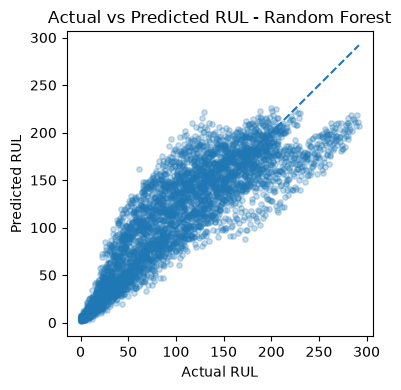

In [23]:
best_raw_name = regression_results_df.drop(index="Median baseline").index[0]
best_raw_pred = raw_predictions[best_raw_name]

plt.figure(figsize=(4, 4))
plt.scatter(y_val, best_raw_pred, alpha=0.25, s=15)
limit = max(y_val.max(), best_raw_pred.max())
plt.plot([0, limit], [0, limit], linestyle="--", linewidth=1.5)
plt.title(f"Actual vs Predicted RUL - {best_raw_name}")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.tight_layout()
plt.show()

# Part II - Time-series feature engineering

The raw model only sees the current sensor snapshot. But degradation is fundamentally about **change through time**.

An engine with a sensor reading of 100 over the last x days is much different than an engine that has a sensor go from 0 -> 100 over the same last x days.

Historical features to add:

1. **Lag features** - previous sensor readings
2. **Rolling mean** - recent average sensor level
3. **Rolling standard deviation** - recent instability/variability
4. **Change features** - difference from the prior cycle
5. **Rolling slope** - direction and speed of recent sensor movement

All calculations are done **within each engine** and use only the current and previous cycles. No future measurements are used.

## 1.) Selecting the top sensors
A smaller set of sensors (8) is chosen because it adds computation workload and many more correlated features.  The set of sensors is chosen by how strong the monotonic relationship it has with the cycle variable in the model training engines
Calculating slopes for every sensor is possible, but it adds computation and many correlated features. We choose a small set of sensors that show the strongest monotonic relationship with **cycle** in the model-training engines.

*This selection should only use the training split and does not look at validation engines.*

In [24]:
scores = {}

for sensor in sensor_cols:
    if reg_train[sensor].nunique() <= 1:
        continue
        
    corr = reg_train[[sensor, "cycle"]].corr(method = "spearman").iloc[0,1]
    
    if pd.notna(corr):
        scores[sensor] = abs(corr)



In [25]:
(pd.Series(scores, name = "abs_spearman_corr_w/_cycle")
 .sort_values(ascending = False)
)

sensor_11   0.622
sensor_4    0.614
sensor_12   0.602
sensor_7    0.586
sensor_15   0.578
sensor_20   0.575
sensor_21   0.571
sensor_17   0.559
sensor_2    0.538
sensor_3    0.531
sensor_13   0.474
sensor_8    0.469
sensor_9    0.416
sensor_14   0.302
sensor_6    0.109
Name: abs_spearman_corr_w/_cycle, dtype: float64

In [26]:
trend_sensors = (pd.Series(scores, name = "abs_spearman_corr_w/_cycle")
    .sort_values(ascending = False)
    .head(8) # taking the top 8 sensors
    .index
    .tolist()
                )

## 2.) Historical feature-engineering function

This function creates 4 types of time series features
- lag - for each row shift the variable back x rows
- mean - for x window size, take the mean of the row plus x - 1 rows before
- std - for x window size, take the std of the row plus x - 1 rows before
- slope - 




This function is reusable for training, validation, and test trajectories.

- `shift()` creates lag features without looking forward.
- rolling windows restart for each engine.
- early-cycle lags/slope values are naturally missing; the model pipeline will median-impute early cycle lag values.

In [27]:
def add_history_features(
    df,
    sensors, # set of sensors to add time series features to
    lag_periods = (1, 5, 10),
    rolling_windows = (5, 20),
    slope_sensors = None, # smaller subset of sensors to add slope feature to
    slope_window = 20,
):
    '''Create past/current-only time-series features within each engine.'''
    out = df.sort_values(["engine_id", "cycle"]).copy()

    # Lag, rolling, and one-cycle change features.
    for sensor in sensors:
        # create time series feature engineering within each engine as to not leak per engine data
        grouped = out.groupby("engine_id")[sensor]

        for lag in lag_periods:
            # lag feature.  Return x lag row before
            out[f"{sensor}_lag_{lag}"] = grouped.shift(lag)

        for window in rolling_windows:
            # rolling mean/std, create a window of x rows and get their mean. 
            # rolling_windows is the number of rows captured
            # min_periods = 1 is the minimum number of rows to capture in a window (the first row's mean will be it's own value, etc)
            out[f"{sensor}_roll_mean_{window}"] = grouped.transform(
                lambda s: s.rolling(window = window, min_periods = 1).mean()
            )
            
            out[f"{sensor}_roll_std_{window}"] = grouped.transform(
                lambda s: s.rolling(window = window, min_periods = 2).std()
            )

        out[f"{sensor}_change_1"] = grouped.diff(1)

    # Rolling slope m, (y = mx + b) on a smaller sensor subset for efficiency.
    if slope_sensors is None:
        slope_sensors = []

    def slope(values):
        x = np.arange(len(values))
        if len(values) < 3 or np.all(values == values[0]):
            return 0.0
        return np.polyfit(x, values, 1)[0]

    for sensor in slope_sensors:
        out[f"{sensor}_slope_{slope_window}"] = (
            out.groupby("engine_id")[sensor]
            .transform(
                lambda s: s.rolling(
                    window = slope_window,
                    min_periods = max(3, slope_window // 2),
                ).apply(slope, raw = True)
            )
        )

    return out

In [28]:
reg_train_hist = add_history_features(
    reg_train,
    sensors = sensor_cols,
    slope_sensors = trend_sensors,
)

reg_val_hist = add_history_features(
    reg_val,
    sensors = sensor_cols,
    slope_sensors = trend_sensors,
)

# Candidate model columns exclude IDs and targets.
exclude_cols = {"engine_id", "rul", "failure_cycle"}

history_candidate_features = [
    col for col in reg_train_hist.columns
    if col not in exclude_cols
]

# Remove features constant in the model-training engines.
history_features = [
    col for col in history_candidate_features
    if reg_train_hist[col].nunique(dropna=False) > 1
]

# print(f"Raw features:        {len(raw_features)}")
print(f"Engineered features: {len(history_features)}")
display(reg_train_hist[history_features[:15]].head())

Engineered features: 182


,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15
192,1,-0.002,0.001,641.890,"1,583.840","1,391.280",21.600,554.530,"2,388.010","9,054.720",46.930,522.330,"2,388.060","8,137.720",8.390
193,2,0.004,-0.000,641.820,"1,587.050","1,393.130",21.610,554.770,"2,387.980","9,051.310",47.240,522.700,"2,387.980","8,131.090",8.417
194,3,0.002,0.000,641.550,"1,588.320","1,398.960",21.600,555.140,"2,388.040","9,054.240",47.220,522.580,"2,387.990","8,140.580",8.380
195,4,0.004,-0.000,641.680,"1,584.150","1,396.080",21.610,554.250,"2,387.980","9,058.010",47.100,522.490,"2,387.930","8,140.440",8.402
196,5,0.001,0.000,641.730,"1,579.030","1,402.520",21.600,555.120,"2,388.030","9,058.150",47.250,522.270,"2,387.940","8,136.670",8.387


## 3.) Comparing results w/ Baseline 

> **Does adding recent sensor history improve prediction compared with using only the current sensor snapshot?**

In [29]:
X_train_hist = reg_train_hist[history_features]
X_val_hist = reg_val_hist[history_features]

y_train_hist = reg_train_hist["rul"]
y_val_hist = reg_val_hist["rul"]

history_models = {
    "Random Forest + history": clone(random_forest_reg),
    "XGBoost + history": clone(xgb_reg),
}

history_results = []
fitted_history_models = {}
history_predictions = {}

for name, model in history_models.items():
    metrics, fitted_model, pred = evaluate_regressor(
        name,
        model,
        X_train_hist,
        y_train_hist,
        X_val_hist,
        y_val_hist,
    )
    history_results.append(metrics)
    fitted_history_models[name] = fitted_model
    history_predictions[name] = pred

history_results_df = pd.DataFrame(history_results).set_index("model")

comparison_df = pd.concat([
    regression_results_df.loc[["Random Forest", "XGBoost"]],
    history_results_df,
]).sort_values("rmse")

display(comparison_df)

,mae,rmse,r2,fit_time_sec
model,,,,
XGBoost + history,24.060,32.842,0.755,1.797
Random Forest,25.437,33.895,0.739,0.976
XGBoost,25.809,34.202,0.735,0.529
Random Forest + history,25.841,34.374,0.732,2.368


In [30]:
# Quantify the improvement from raw XGBoost to historical XGBoost.
raw_rmse = regression_results_df.loc["XGBoost", "rmse"]
hist_rmse = history_results_df.loc["XGBoost + history", "rmse"]

rmse_improvement_pct = (raw_rmse - hist_rmse) / raw_rmse * 100

print(f"Raw XGBoost RMSE:        {raw_rmse:.2f} cycles")
print(f"History XGBoost RMSE:    {hist_rmse:.2f} cycles")
print(f"Relative RMSE change:    {rmse_improvement_pct:.1f}%")

Raw XGBoost RMSE:        34.20 cycles
History XGBoost RMSE:    32.84 cycles
Relative RMSE change:    4.0%


## 4.) Error analysis by proximity to failure

One aggregate RMSE can hide where the model struggles. Maintenance decisions are especially sensitive near failure, so we break validation errors into RUL bands.

In [31]:
best_hist_pred = history_predictions["XGBoost + history"]

error_analysis = reg_val_hist[["engine_id", "cycle", "rul"]].copy()
error_analysis["predicted_rul"] = best_hist_pred
error_analysis["absolute_error"] = np.abs(
    error_analysis["rul"] - error_analysis["predicted_rul"]
)

error_analysis["rul_band"] = pd.cut(
    error_analysis["rul"],
    bins=[-1, 30, 60, 100, np.inf],
    labels=["0–30", "31–60", "61–100", "100+"],
)

band_results = (
    error_analysis.groupby("rul_band", observed=False)
    .agg(
        rows=("rul", "size"),
        actual_rul_mean=("rul", "mean"),
        prediction_mean=("predicted_rul", "mean"),
        mae=("absolute_error", "mean"),
    )
)

display(band_results)

,rows,actual_rul_mean,prediction_mean,mae
rul_band,,,,
0–30,620,15.000,16.068,5.166
31–60,600,45.500,59.341,17.519
61–100,800,80.500,104.160,27.714
100+,2035,160.828,156.569,30.308


# Part III - Hyperparameter tuning with grouped cross-validation

Hyperparameter search is more reliable when it evaluates multiple independent groups.

**GroupKFold** groups by `engine_id`. That means an engine can never appear in both the training and validation portion of the same fold.

Using RandomizedSearchCV vs GridSearchCV because XGBoost has many interacting hyperparameters. A full grid can become unnecessarily expensive. Randomized search lets us explore more dimensions with a controlled number of model fits.

> On a slower laptop, reduce `N_ITER` from 15 to 5–10 while learning the workflow.

In [32]:
RUN_TUNING = True # manually turn on tuning when running model

xgb_tuning_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        random_state = RANDOM_STATE,
        n_jobs = 1,  # CV itself is parallelized below.
    )),
])

param_distributions = {
    "model__n_estimators": [250, 400, 600],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.02, 0.05, 0.10],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.70, 0.85, 1.00],
    "model__colsample_bytree": [0.70, 0.85, 1.00],
    "model__reg_alpha": [0.0, 0.01, 0.10],
    "model__reg_lambda": [1.0, 5.0, 10.0],
}

group_cv = GroupKFold(n_splits=5)

if RUN_TUNING:
    reg_search = RandomizedSearchCV(
        estimator = xgb_tuning_pipeline,
        param_distributions = param_distributions,
        n_iter = 15, # reduce if running too slow
        scoring = "neg_root_mean_squared_error",
        cv = group_cv,
        random_state = RANDOM_STATE,
        n_jobs = -1,
        verbose = 1,
        return_train_score = True,
    )

    reg_search.fit(
        X_train_hist,
        y_train_hist,
        groups = reg_train_hist["engine_id"],
    )

    tuned_reg_model = reg_search.best_estimator_

    print("Best grouped-CV RMSE:", -reg_search.best_score_)
    print("Best parameters:")
    display(pd.Series(reg_search.best_params_))
else:
    tuned_reg_model = fitted_history_models["XGBoost + history"]
    print("Tuning skipped; using baseline historical XGBoost.")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best grouped-CV RMSE: 37.85179901123047
Best parameters:


model__subsample            0.700
model__reg_lambda           5.000
model__reg_alpha            0.000
model__n_estimators       400.000
model__min_child_weight     3.000
model__max_depth            2.000
model__learning_rate        0.020
model__colsample_bytree     0.700
dtype: float64

In [33]:
# Evaluate the selected/tuned model once on the untouched validation engines.
# The validation engines were not used inside RandomizedSearchCV.

tuned_val_pred = np.clip(tuned_reg_model.predict(X_val_hist), 0, None)
tuned_val_metrics = regression_metrics(y_val_hist, tuned_val_pred)

print("Validation performance of selected regression model:")
display(pd.Series(tuned_val_metrics).to_frame("value"))

Validation performance of selected regression model:


,value
mae,24.129
rmse,32.211
r2,0.765


# Part IV - Variable Explainability/Importance with SHAP

Feature importance tells us **which inputs matter**, but SHAP gives a richer view:

- how important each feature is overall
- whether high or low values tend to increase/decrease predicted RUL
- which features drove an individual prediction

For speed, we explain a random sample of validation rows instead of every observation.

In [34]:
# Pull the fitted imputer and XGBoost model out of the pipeline.
reg_imputer = tuned_reg_model.named_steps["imputer"]
reg_xgb = tuned_reg_model.named_steps["model"]

shap_sample = X_val_hist.sample(
    n = min(1000, len(X_val_hist)),
    random_state = RANDOM_STATE,
)

shap_sample_imputed = reg_imputer.transform(shap_sample)

explainer = shap.TreeExplainer(reg_xgb)
shap_values = explainer.shap_values(shap_sample_imputed)

# Global importance table.
mean_abs_shap = np.abs(shap_values).mean(axis = 0)
shap_importance = (
    pd.DataFrame({
        "feature": history_features,
        "mean_abs_shap": mean_abs_shap,
    })
    .sort_values("mean_abs_shap", ascending = False)
)

display(shap_importance.head(20))

,feature,mean_abs_shap
0,cycle,27.971
43,sensor_4_roll_mean_5,7.070
171,sensor_21_roll_mean_20,4.084
121,sensor_14_roll_mean_20,4.018
127,sensor_15_roll_mean_5,3.435
174,sensor_11_slope_20,3.367
95,sensor_11_roll_mean_5,3.116
83,sensor_9_roll_mean_20,2.151
176,sensor_12_slope_20,2.145
113,sensor_13_roll_mean_20,1.785


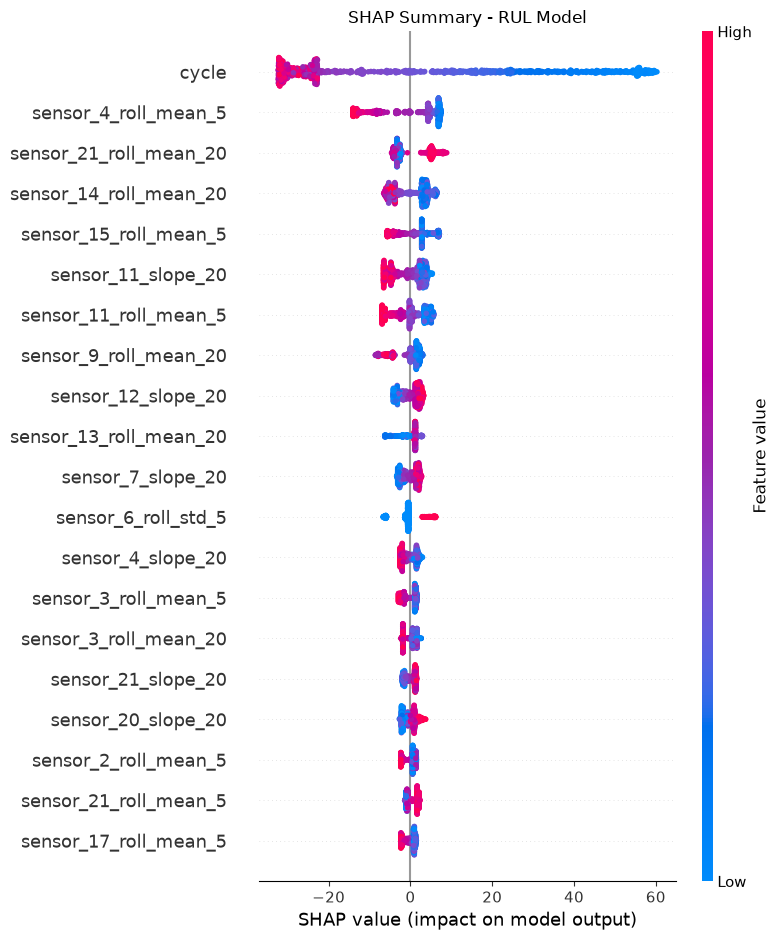

In [35]:
# SHAP beeswarm-style summary plot.
shap.summary_plot(
    shap_values,
    shap_sample_imputed,
    feature_names=history_features,
    max_display=20,
    show=False,
)
plt.title("SHAP Summary - RUL Model")
plt.tight_layout()
plt.show()

**Interpreting SHAP**

A feature being important does **not** mean it causes failure. It means the model relies on that feature to make predictions in this dataset.

Engineered time series variables rank highly, which supports the hypothesis that **sensor history contains information beyond the current snapshot**.

# Part V - Final regression model and NASA test-set evaluation

The validation set has now served its purpose: model selection and tuning.

For the final model we:

1. Create historical features for the *entire NASA training fleet
2. Refit the selected pipeline on all 100 training engines
3. Create the same historical features for the NASA test trajectories.
4. Keep only the last observed cycle of each test engine
5. Predict how many cycles remain
6. Compare those predictions with NASA's supplied `RUL_FD001.txt` values.

In [36]:
# Create features for all available training and test trajectories.
full_train_hist = add_history_features(
    train,
    sensors = sensor_cols,
    slope_sensors = trend_sensors,
)

full_test_hist = add_history_features(
    test,
    sensors = sensor_cols,
    slope_sensors = trend_sensors,
)


In [37]:
# Keep the exact feature list chosen earlier from the training split.
X_full_train = full_train_hist[history_features]
y_full_train = full_train_hist["rul"]

final_reg_model = clone(tuned_reg_model)
final_reg_model.fit(X_full_train, y_full_train)

# RUL is the last observed cycle of each test engine.
test_last = (
    full_test_hist.sort_values(["engine_id", "cycle"])
    .groupby("engine_id", as_index=False)
    .tail(1)
    .sort_values("engine_id")
)

In [38]:
X_test_last = test_last[history_features]
final_test_pred = np.clip(final_reg_model.predict(X_test_last), 0, None)

final_test_results = test_last[["engine_id", "cycle"]].copy()
final_test_results = final_test_results.merge(test_rul, on = "engine_id", how = "left")
final_test_results["predicted_rul"] = final_test_pred
final_test_results["absolute_error"] = np.abs(
    final_test_results["rul"] - final_test_results["predicted_rul"]
)

final_reg_metrics = regression_metrics(
    final_test_results["rul"],
    final_test_results["predicted_rul"],
)

In [39]:
print("NASA FD001 final-cycle test performance:")
display(pd.Series(final_reg_metrics).to_frame("value"))
display(final_test_results.head(10))

NASA FD001 final-cycle test performance:


,value
mae,19.253
rmse,25.746
r2,0.616


,engine_id,cycle,rul,predicted_rul,absolute_error
0,1,31,112,184.449,72.449
1,2,49,98,156.566,58.566
2,3,126,69,46.841,22.159
3,4,106,82,79.054,2.946
4,5,98,91,100.948,9.948
5,6,105,93,112.179,19.179
6,7,160,91,107.065,16.065
7,8,166,95,77.670,17.330
8,9,55,111,148.066,37.066
9,10,192,96,94.168,1.832


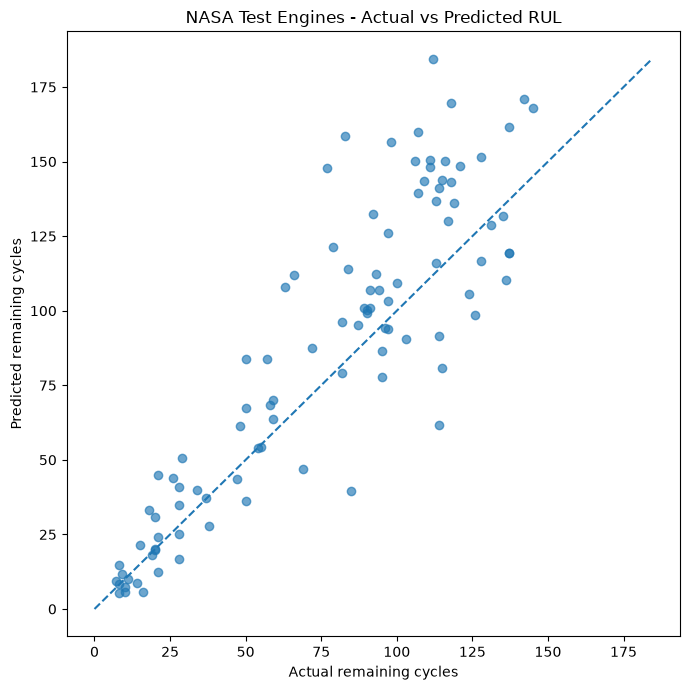

In [40]:
plt.figure(figsize=(7, 7))
plt.scatter(
    final_test_results["rul"],
    final_test_results["predicted_rul"],
    alpha=0.65,
)
limit = max(
    final_test_results["rul"].max(),
    final_test_results["predicted_rul"].max(),
)
plt.plot([0, limit], [0, limit], linestyle="--", linewidth=1.5)
plt.title("NASA Test Engines - Actual vs Predicted RUL")
plt.xlabel("Actual remaining cycles")
plt.ylabel("Predicted remaining cycles")
plt.tight_layout()
plt.show()

# Part VI - Reframing the question as classification

A regression output such as `RUL = 27` is useful, but many maintenance processes ultimately require a binary action.

We define:
failure_window(30) =>\
if RUL <= 30, 1\
else, 0

*The value 30 is a business assumption.* In reality it should be tied to  things such as maintenance lead time,  downtime risk, and other economics factors, etc.

In [41]:
FAILURE_WINDOW = 30

cls_train = reg_train_hist.copy()
cls_val = reg_val_hist.copy()

cls_train["failure_within_30"] = (cls_train["rul"] <= FAILURE_WINDOW).astype(int)
cls_val["failure_within_30"] = (cls_val["rul"] <= FAILURE_WINDOW).astype(int)

print("Training class distribution:")
display(
    cls_train["failure_within_30"]
    .value_counts()
    .rename("count")
    .to_frame()
    .assign(proportion=lambda d: d["count"] / d["count"].sum())
)

Training class distribution:


,count,proportion
failure_within_30,,
0,14096,0.850
1,2480,0.150


## Classification metrics

- For an imbalanced class, accuracy alone is not enough
- **Recall:** Of engines/cycles actually within the failure window, how many did were flag?
- **Precision:** Of the alerts generated, how many were truly within the failure window?
- **F1:** Balance between precision and recall.
- **ROC-AUC:** Ranking quality across thresholds.
- **PR-AUC / Average Precision:** Especially useful when the positive class is less common.

In this project, the assumption is, **missing an imminent failure is more expensive than issuing an extra inspection**, so recall will be the most important metric here.

In [42]:
def classification_metrics(y_true, prob, threshold = 0.50):
    pred = (prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division = 0),
        "recall": recall_score(y_true, pred, zero_division =0),
        "f1": f1_score(y_true, pred, zero_division = 0), 
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
    }


def evaluate_classifier(name, model, X_train, y_train, X_val, y_val):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start

    prob = model.predict_proba(X_val)[:, 1]
    metrics = classification_metrics(y_val, prob, threshold = 0.50)
    metrics["fit_time_sec"] = fit_time
    metrics["model"] = name

    return metrics, model, prob

## Classification model comparison

Reusing the engineered historical features.

Because the failure-window class is not evenly distributed, Logistic Regression and Random Forest use balanced class weights. 

For XGBoost, calculating `scale_pos_weight` from the training data.

In [43]:
X_cls_train = cls_train[history_features]
y_cls_train = cls_train["failure_within_30"]
X_cls_val = cls_val[history_features]
y_cls_val = cls_val["failure_within_30"]

negative_count = (y_cls_train == 0).sum()
positive_count = (y_cls_train == 1).sum()
scale_pos_weight = negative_count / positive_count

logistic_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

random_forest_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

classification_models = {
    "Logistic Regression": logistic_cls,
    "Random Forest": random_forest_cls,
    "XGBoost": xgb_cls,
}

In [44]:
classification_results = []
fitted_classifiers = {}
classification_probabilities = {}

for name, model in classification_models.items():
    metrics, fitted_model, prob = evaluate_classifier(
        name,
        model,
        X_cls_train,
        y_cls_train,
        X_cls_val,
        y_cls_val,
    )
    classification_results.append(metrics)
    fitted_classifiers[name] = fitted_model
    classification_probabilities[name] = prob

classification_results_df = (
    pd.DataFrame(classification_results)
    .set_index("model")
    .sort_values("pr_auc", ascending=False)
)

display(classification_results_df)

,accuracy,precision,recall,f1,roc_auc,pr_auc,fit_time_sec
model,,,,,,,
XGBoost,0.976,0.903,0.942,0.922,0.996,0.980,1.549
Logistic Regression,0.970,0.860,0.961,0.908,0.996,0.979,0.727
Random Forest,0.968,0.872,0.926,0.898,0.994,0.971,1.617


## Tune the XGBoost failure classifier with grouped cross-validation

We tune the classifier separately from the RUL regressor because the objective and evaluation metric are different.

For the failure-alert problem, the search optimizes **average precision (PR-AUC)** rather than accuracy.

In [45]:
RUN_CLASSIFIER_TUNING = True

xgb_cls_tuning_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("model", XGBClassifier(
        scale_pos_weight = scale_pos_weight,
        objective = "binary:logistic",
        eval_metric = "logloss",
        random_state = RANDOM_STATE,
        n_jobs = 1,
    )),
])

cls_param_distributions = {
    "model__n_estimators": [250, 350, 500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.02, 0.05, 0.10],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.70, 0.85, 1.00],
    "model__colsample_bytree": [0.70, 0.85, 1.00],
    "model__reg_alpha": [0.0, 0.01, 0.10],
    "model__reg_lambda": [1.0, 5.0, 10.0],
}

if RUN_CLASSIFIER_TUNING:
    cls_search = RandomizedSearchCV(
        estimator = xgb_cls_tuning_pipeline,
        param_distributions = cls_param_distributions,
        n_iter = 10, # reduced because of long run times
        scoring = "average_precision",
        cv = GroupKFold(n_splits = 5),
        random_state = RANDOM_STATE,
        n_jobs = -1,
        verbose = 1,
        return_train_score = True,
    )

    cls_search.fit(
        X_cls_train,
        y_cls_train,
        groups=cls_train["engine_id"],
    )

    tuned_classifier = cls_search.best_estimator_
    tuned_cls_prob = tuned_classifier.predict_proba(X_cls_val)[:, 1]
    tuned_cls_metrics = classification_metrics(
        y_cls_val,
        tuned_cls_prob,
        threshold=0.50,
    )
    tuned_cls_metrics["fit_time_sec"] = np.nan

    fitted_classifiers["Tuned XGBoost"] = tuned_classifier
    classification_probabilities["Tuned XGBoost"] = tuned_cls_prob
    classification_results_df.loc["Tuned XGBoost"] = tuned_cls_metrics
    classification_results_df = classification_results_df.sort_values(
        "pr_auc", ascending=False
    )

    print("Best grouped-CV PR-AUC:", cls_search.best_score_)
    print("Best parameters:")
    display(pd.Series(cls_search.best_params_))
    print("\nUpdated validation comparison:")
    display(classification_results_df)
else:
    print("Classifier tuning skipped.")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best grouped-CV PR-AUC: 0.9701714033903033
Best parameters:


model__subsample            0.700
model__reg_lambda           5.000
model__reg_alpha            0.010
model__n_estimators       250.000
model__min_child_weight     1.000
model__max_depth            3.000
model__learning_rate        0.050
model__colsample_bytree     0.850
dtype: float64


Updated validation comparison:


,accuracy,precision,recall,f1,roc_auc,pr_auc,fit_time_sec
model,,,,,,,
XGBoost,0.976,0.903,0.942,0.922,0.996,0.980,1.549
Tuned XGBoost,0.971,0.864,0.965,0.912,0.996,0.980,NaN
Logistic Regression,0.970,0.860,0.961,0.908,0.996,0.979,0.727
Random Forest,0.968,0.872,0.926,0.898,0.994,0.971,1.617


## Precision-recall curve

The curve shows the tradeoff created by changing the probability threshold. Lowering the threshold usually increases recall but creates more false alarms.

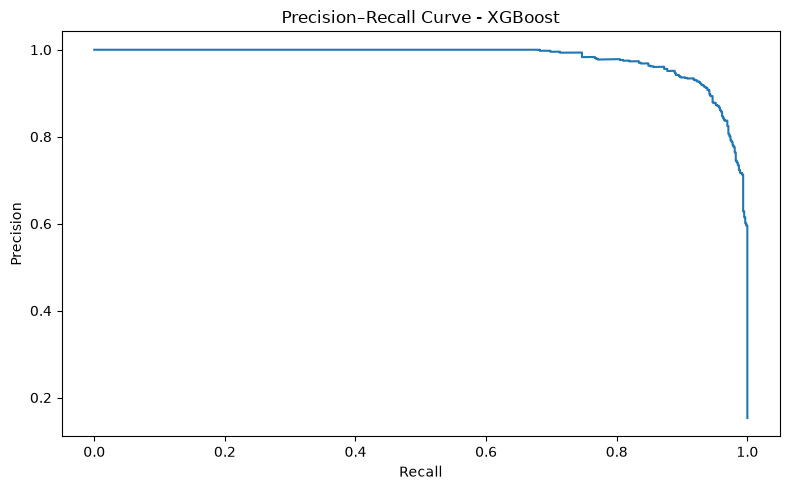

Best classifier at default 0.50 threshold:


,value
accuracy,0.976
precision,0.903
recall,0.942
f1,0.922
roc_auc,0.996
pr_auc,0.980


In [46]:
best_classifier_name = classification_results_df.index[0]
best_classifier = fitted_classifiers[best_classifier_name]
best_val_prob = classification_probabilities[best_classifier_name]

precision, recall, thresholds = precision_recall_curve(y_cls_val, best_val_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.title(f"Precision–Recall Curve - {best_classifier_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

print("Best classifier at default 0.50 threshold:")
display(pd.Series(
    classification_metrics(y_cls_val, best_val_prob, threshold=0.50)
).to_frame("value"))

# Part VII - Threshold optimization using maintenance economics

Now that there's a model that can predict when a machine could fail, it is up to the business to decide when to take action.
The model produces probabilities; the business chooses the action threshold.

Assumptions:

- **False positive:** an unnecessary early inspection costs **5,000**
- **False negative:** an imminent failure is missed and costs **100,000**

These are illustrative, made up, assumptions for educational purposes only. 

NOT NASA cost figures.

In [47]:
COST_FALSE_POSITIVE = 5_000
COST_FALSE_NEGATIVE = 100_000

threshold_grid = np.arange(0.05, 0.96, 0.01)
threshold_rows = []

for threshold in threshold_grid:
    pred = (best_val_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_cls_val, pred, labels = [0, 1]).ravel()

    total_cost = (
        fp * COST_FALSE_POSITIVE
        + fn * COST_FALSE_NEGATIVE
    )

    threshold_rows.append({
        "threshold": threshold,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": precision_score(y_cls_val, pred, zero_division=0),
        "recall": recall_score(y_cls_val, pred, zero_division=0),
        "f1": f1_score(y_cls_val, pred, zero_division=0),
        "estimated_cost": total_cost,
    })

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.loc[
    threshold_results["estimated_cost"].idxmin()
]

selected_threshold = float(best_threshold_row["threshold"])

print(f"Selected cost-minimizing threshold: {selected_threshold:.2f}")
display(best_threshold_row.to_frame("value"))

Selected cost-minimizing threshold: 0.06


,value
threshold,0.060
tn,"3,239.000"
fp,196.000
fn,11.000
tp,609.000
precision,0.757
recall,0.982
f1,0.855
estimated_cost,"2,080,000.000"


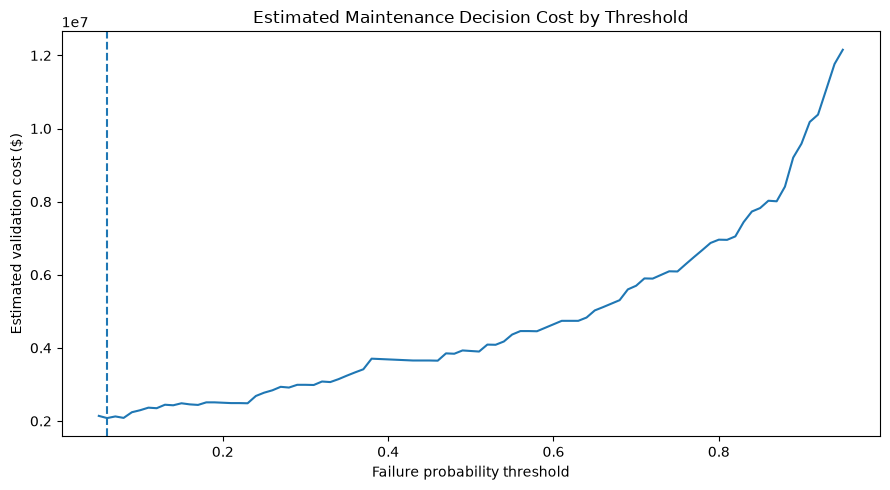

In [48]:
plt.figure(figsize = (9, 5))
plt.plot(threshold_results["threshold"], threshold_results["estimated_cost"])
plt.axvline(selected_threshold, linestyle = "--", linewidth = 1.5)
plt.title("Estimated Maintenance Decision Cost by Threshold")
plt.xlabel("Failure probability threshold")
plt.ylabel("Estimated validation cost ($)")
plt.tight_layout()
plt.show()

### Compare the default and cost-optimized thresholds

This is the bridge between model metrics and business decision-making. A lower-cost threshold may intentionally sacrifice some precision to catch more imminent failures.

In [49]:
threshold_comparison = pd.DataFrame({
    "threshold_0.50": classification_metrics(
        y_cls_val, best_val_prob, threshold = 0.50
    ),
    "cost_optimized": classification_metrics(
        y_cls_val, best_val_prob, threshold = selected_threshold
    ),
}).T

display(threshold_comparison)
print(f"{selected_threshold}%")

,accuracy,precision,recall,f1,roc_auc,pr_auc
threshold_0.50,0.976,0.903,0.942,0.922,0.996,0.980
cost_optimized,0.949,0.757,0.982,0.855,0.996,0.980


0.060000000000000005%


## Final classification evaluation on NASA test engines

We now refit the selected classifier on the full training fleet. The threshold stays fixed at the value selected using validation engines.

NASA supplies the true final-cycle RUL for each test engine, so we can convert those RUL values into the same <= 30 cycles classification target.

In [50]:
# metrics for conclusion

full_train_cls = full_train_hist.copy()
full_train_cls["failure_within_30"] = (
    full_train_cls["rul"] <= FAILURE_WINDOW
).astype(int)

X_full_cls = full_train_cls[history_features]
y_full_cls = full_train_cls["failure_within_30"]

final_classifier = clone(best_classifier)
final_classifier.fit(X_full_cls, y_full_cls)

final_test_prob = final_classifier.predict_proba(X_test_last)[:, 1]
final_test_true_cls = (test_rul["rul"] <= FAILURE_WINDOW).astype(int).to_numpy()

final_cls_metrics = classification_metrics(
    final_test_true_cls,
    final_test_prob,
    threshold = selected_threshold,
)

print("NASA final-cycle classification performance:")
display(pd.Series(final_cls_metrics).to_frame("value"))

final_test_cls_pred = (final_test_prob >= selected_threshold).astype(int)
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(final_test_true_cls, final_test_cls_pred, labels=[0, 1]))

NASA final-cycle classification performance:


,value
accuracy,0.940
precision,0.806
recall,1.000
f1,0.893
roc_auc,0.990
pr_auc,0.971


Confusion matrix [[TN, FP], [FN, TP]]:
[[69  6]
 [ 0 25]]


In [51]:
import json
import joblib

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents = True, exist_ok = True)

# Save final trained models
joblib.dump(final_reg_model, OUTPUT_DIR / "rul_regression_model.joblib")
joblib.dump(final_classifier, OUTPUT_DIR / "failure_classifier.joblib")

# Save configuration used to recreate predictions
with open(OUTPUT_DIR / "model_config.json", "w") as f:
    json.dump({
        "feature_names": history_features,
        "failure_window_cycles": FAILURE_WINDOW,
        "selected_probability_threshold": selected_threshold,
        "false_positive_cost_assumption": COST_FALSE_POSITIVE,
        "false_negative_cost_assumption": COST_FALSE_NEGATIVE,
        "random_state": RANDOM_STATE,
    }, f, indent=2)

# Save final regression predictions on NASA test engines
final_test_results.to_csv(
    OUTPUT_DIR / "nasa_test_rul_predictions.csv",
    index = False
)

# Save final classification predictions on NASA test engines
final_test_failure_results = test_last[["engine_id", "cycle"]].copy()
final_test_failure_results = final_test_failure_results.merge(
    test_rul, on = "engine_id", how = "left"
)
final_test_failure_results["actual_failure_within_30"] = (
    final_test_failure_results["rul"] <= FAILURE_WINDOW
).astype(int)
final_test_failure_results["predicted_failure_probability"] = final_test_prob
final_test_failure_results["predicted_failure_within_30"] = (
    final_test_prob >= selected_threshold
).astype(int)

final_test_failure_results.to_csv(
    OUTPUT_DIR / "nasa_test_failure_predictions.csv",
    index=False
)

# Save a compact final metrics summary
with open(OUTPUT_DIR / "final_metrics_summary.json", "w") as f:
    json.dump({
        "regression_test_metrics": final_reg_metrics,
        "classification_test_metrics": final_cls_metrics,
    }, f, indent=2)

# Part VIII Conclusions, recommendations, and next steps
## A.) The project produced model capable of predicting remaining engine life much better than a simple baseline
- The first major step of the project was create a baseline model that simply predicted the median RUL for every engine.  It had a validation MAE of 55.6 cycles and RMSE of 66.4 cycles.
- Next, a couple of machine learning models were trained (linear regression, decision tree, random forest, XGboost) and the best model was Random Forest with RMSE of 33.9.
- After selecting the model, tuning, testing it with cross validation, and retraining using all available training data, the final RUL model achived the following results on the official test data:
| Metric | Value |
| --- | --- |
| MAE | 19.3 cycles |
| RMSE | 25.8 cycles |
| R squared | 0.616 |

- The final model's RUL predictions on average were of by 19 cycles.  Larger prediction errors increased RMSE to about 26 cycles, suggesting that some engines were more difficult to predict than others.  The model explained about 62% of the variation in RUL across the test engines.

## B.) Reframing the problem/question as a classifcation project provides useful maintence warnings
- Another model was built to answer a more "business focused" question: **How likely is this engine to fail within the next 30 cycles**
- The strongest model was XGBoost with validation PR-AUC of 0.980.
- This assumes a normal probability cutoff of 0.50
| Metric | Value |
| --- | --- |
| Precision | 0.903 |
| Recall | 0.942 |


## C.) Using business/economic assumptions, we can tune the model to better meet the business needs
- In reality, missing an engine that is close to failure could be much more expensive than performing an unnecssary inspection.
- In other words, the cost of a false negative is much greater than a false positive.
- By sacrificing the model's precision for recall, the model will better predict actual business/economic outcomes
- This notebook assumes/makes up the example cost of 100,000 dollars  for each missed failure (false negative) and 5000 for each unnecessary inspection (false postiive)
- Recalibrating the model to these parameters, the best validation threshold would be 0.06 instead of 0.50 and the following metrics:

| Metric | Value |
| --- | --- |
| Precision | 0.757 |
| Recall | 0.982 |

- Using these assumptions and test data, the estimated savings versus the baseline 0.50 model saves about $2 million (47% reduction)
- This lower threshold makes the model more likely to issue maintenence warnings which creates more false alarms, but greatly reduces the chance of missing an engine that is actually close to failure


## Other Findings:
### 1.) Sensor history improves predictions
- Additional time series variables were created to describe how sensor readings changed over time:
    - Lag: previous sensor reading
    - Rolling mean
    - Rolling std
    - Recent sensor trends (slope, m)
- SHAP analysis gives more evidence to these findings as many of the top important features were time-series features
    1. cycle
    2. sensor_4_roll_mean_5
    3. sensor_21_roll_mean_20
    4. sensor14_roll_mean_20
    5. sensor_15_roll_mean_5
- This only explains how the model is making predictions and not inherently suggesting causation.
### 2.) Errors are smaller and more important closer to engine failure
- The model does not perform equally well during every stage of an engine's life
- For example, MAE was 30.3 cycles for engines with more than 100 actual remaining cycles
- The MAE dropped to 5.2 cycles when the engine had only less than 30 cycles remaining actual
- This suggests predictions close to failure are more important for maintenence decisions
- Because of this, future models should bge judged not only by their overal RMSE, but also by how accurately it predicts engines that are closer to failure

## Business Recommendations:
1. **Use predicted RUL to help prioritize maintenence.**
    - Scheduled maintenance should incorporate RUL metric to better determine machines to prioritize
2. **Classifer model (30/x cycles) should be used as an additional warning system.**
    - Using both models gives more dimensions to the situation
    - "How much life is left" vs "Does this engine need attention soon"
3. **Choose an alert threshold based on real business costs**
    - Other subject matter experts should be consulted to calculate the actual costs for machine breakdowns versus inspection to come up with a threshold that achives maximum business savings
4. **Subject matter experts should pay attention to the most important sensors and their trends**
    - The SHAP analysis can help the engineering team identify which sensors may deserve closer monitoring.  These sensors readings should be more readily available in say a dashboard
5. **Keep engineering/maintenence professionals/other subject matter experts involved in the final decision**
    - The model should be used as a decision support tool rather than an autopilot system.  Predictions should be considered together with other things such as regular inspections, maintenance history, etc.
  
## Project Limitations
- C-MAPSS is simulated data.  Real data has more noise
- RUL model only gives one estimate.  For example, the model can predict a machine has 25 remaining cycles but it does not currently say how confident it is in that estimate
- 30 cycle warning was a arbitrary number.  Real business would analyze when the actual warning should occur
- Mainenance costs (100k, 5k) were arbitrary numbers used to illustrate the best probability threshold.  Real business would analyze the actual costs
- SHAP does not prove cause and effect.
- Some multicolinearity with engine data as measurements collected over time from one engine are still naturally connected.  Selected models are decently robust to multicolinearity however

## Recommended Next Steps
1. Create additional historical sensor features
    - no reason to assume the metrics selected here are the best. other metric examples include rolling min/max values, historical delta, changing the lagperiods/window sizes
2. Add confidence/uncertainty to the RUL predictions
    - Instread of only predicting a static RUL value, a more useful metric for business purposes would be x cycles remaining plus or minus y. 
3. Predict several maintenance windows
   - Label cycle warnings such as RUL: 15= urgent, 30 = needs maintenence, 60 =order parts, etc
4. If the model is accepted, plan how the model would be used/monitored in production
   - A real predictive maintenence model would need to be monitored after deployment
   - The model should be retrained when there is evidence that its performance has changed or real world factors (for example new types of machines, cost change, etc)

## Overall Conclusion

This notebook/project demonstrates more than simply fitting an XGBoost model.  It aims to build builds a predictive maintenance workflow that connects multivariate sensor data, time-series feature engineering, grouped validation, regression, classification, explainability, anomaly detection, and cost-sensitive decision-making.

The most important practical lesson is that predictive maintenance is not only a question of maximizing a model metric.  A useful system must identify deterioration early enough to support action, control the cost of false alarms and missed failures, explain which signals are influencing predictions, and continue to perform on completely unseen equipment.